# 07 — Dataset Assembly

Merge optical + terrain into 8-channel samples, split spatially, normalise.

| Decision | Choice | Why |
|---|---|---|
| Channels | B02,B03,B04,B08,NDVI,slope,hillshade,curvature | Surface appearance + terrain geometry. Neither alone predicts failure. |
| Elevation EXCLUDED | deliberate | Notebook 06 found positives sit 255 m higher on average. Including absolute elevation would hand the model a shortcut ("high ground = landslide") instead of forcing it to learn terrain shape. Slope, hillshade and curvature are all elevation-invariant. |
| Split | whole 10 km blocks -> train/val/test | Random splitting puts a patch and its neighbour on opposite sides and inflates scores by 10-20 points. |
| Normalisation | z-score from TRAIN statistics only | Using all patches leaks the test distribution into training. |
| Augmentation | flips + 90 deg rotations; brightness on optical only | Landslides have no canonical orientation. Hillshade encodes a fixed sun angle, so brightness jitter on it would be physically meaningless. |
| Elevation band subset | saved for notebook 08 | Lets us re-test within an overlapping elevation range and show the model isn't just reading altitude. |

Output: X.npy, y.npy, split.csv (FROZEN), norm_stats.json

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm

PROJECT_DIR = Path("..").resolve()
COORD_CSV   = PROJECT_DIR / "data" / "coordinates" / "all_coordinates.csv"
OPTICAL_DIR = PROJECT_DIR / "data" / "pre_event" / "native_tif"
TERRAIN_DIR = PROJECT_DIR / "data" / "terrain" / "patches"   # <- patches subfolder
META_DIR    = PROJECT_DIR / "data" / "metadata"
PROC_DIR    = PROJECT_DIR / "data" / "processed"
SPLIT_DIR   = PROJECT_DIR / "data" / "splits"
FIG_DIR     = PROJECT_DIR / "outputs" / "figures"
for d in (PROC_DIR, SPLIT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

CHANNELS = ["B02", "B03", "B04", "B08", "NDVI",
            "slope", "hillshade", "curvature"]
N_CH, PX = len(CHANNELS), 64

BLOCK_M   = 10_000
FRACTIONS = {"train": 0.60, "val": 0.20, "test": 0.20}
CLIP_PCT  = (1, 99)
SEED      = 42

rng = np.random.default_rng(SEED)

assert OPTICAL_DIR.exists() and TERRAIN_DIR.exists()
print(f"optical tifs : {len(list(OPTICAL_DIR.glob('*.tif')))}")
print(f"terrain tifs : {len(list(TERRAIN_DIR.glob('*.tif')))}")
print(f"{N_CH} channels: {CHANNELS}")

optical tifs : 3020
terrain tifs : 3024
8 channels: ['B02', 'B03', 'B04', 'B08', 'NDVI', 'slope', 'hillshade', 'curvature']


In [2]:
coords  = pd.read_csv(COORD_CSV)
prog    = pd.read_csv(META_DIR / "pre_event_progress.csv")
terrain = pd.read_csv(META_DIR / "terrain_features.csv")

ok_opt = set(prog.query("status == 'success'").landslide_id)
ok_ter = set(terrain.query("status == 'success'").landslide_id)

rows = []
for r in coords.itertuples():
    pid = r.landslide_id
    if (pid in ok_opt and pid in ok_ter
            and (OPTICAL_DIR / f"{pid}.tif").exists()
            and (TERRAIN_DIR / f"{pid}.tif").exists()):
        rows.append({"landslide_id": pid, "label": r.label,
                     "utm_x": r.utm_x, "utm_y": r.utm_y,
                     "longitude": r.longitude, "latitude": r.latitude})

df = pd.DataFrame(rows)
# carry elevation through for the notebook 08 confound test
df = df.merge(terrain[["landslide_id", "elev_mean", "slope_mean"]],
              on="landslide_id", how="left")

print(f"coordinates      : {len(coords)}")
print(f"optical success  : {len(ok_opt)}")
print(f"terrain success  : {len(ok_ter)}")
print(f"COMPLETE (both)  : {len(df)}")
print(df.label.value_counts().rename({1: "positive", 0: "negative"}))

assert len(df) > 1000, "Too few complete patches"
imb = abs((df.label == 1).sum() - (df.label == 0).sum()) / len(df)
print(f"\nclass imbalance: {imb:.1%}")
assert imb < 0.20, "Classes badly imbalanced — check acquisition per class"
print("CHECKPOINT PASSED")

coordinates      : 3024
optical success  : 3020
terrain success  : 3024
COMPLETE (both)  : 3020
label
positive    1512
negative    1508
Name: count, dtype: int64

class imbalance: 0.1%
CHECKPOINT PASSED


In [3]:
df["block_x"] = (df.utm_x // BLOCK_M).astype(int)
df["block_y"] = (df.utm_y // BLOCK_M).astype(int)
df["block_id"] = df.block_x.astype(str) + "_" + df.block_y.astype(str)

blocks = (df.groupby("block_id")
            .agg(n=("landslide_id", "size"), n_pos=("label", "sum"))
            .reset_index())

print(f"{len(blocks)} spatial blocks ({BLOCK_M/1000:.0f} km)")
print(blocks.n.describe().round(1))
assert len(blocks) >= 20, "Too few blocks — reduce BLOCK_M"
print("CHECKPOINT PASSED")

137 spatial blocks (10 km)
count    137.0
mean      22.0
std       15.8
min        1.0
25%        8.0
50%       20.0
75%       31.0
max       67.0
Name: n, dtype: float64
CHECKPOINT PASSED


In [4]:
# Balance BOTH patch count and positive count across splits. Negatives sit in
# a ring around positives, so blocks are often single-class; assigning on size
# alone loads one split with positives.
blocks = blocks.iloc[rng.permutation(len(blocks))].reset_index(drop=True)

tot_n, tot_p = blocks.n.sum(), blocks.n_pos.sum()
tgt_n = {k: v * tot_n for k, v in FRACTIONS.items()}
tgt_p = {k: v * tot_p for k, v in FRACTIONS.items()}
cur_n = {k: 0 for k in tgt_n}
cur_p = {k: 0 for k in tgt_p}
assign = {}

for _, b in blocks.sort_values("n", ascending=False).iterrows():
    best, best_cost = None, np.inf
    for s in tgt_n:
        # relative fill after adding this block, in both dimensions
        fn = (cur_n[s] + b.n) / tgt_n[s]
        fp = (cur_p[s] + b.n_pos) / max(tgt_p[s], 1)
        cost = fn + fp
        if cost < best_cost:
            best, best_cost = s, cost
    assign[b.block_id] = best
    cur_n[best] += b.n
    cur_p[best] += b.n_pos

df["split"] = df.block_id.map(assign)

summary = (df.groupby("split")
             .agg(patches=("landslide_id", "size"),
                  positive=("label", "sum"),
                  blocks=("block_id", "nunique"))
             .reindex(["train", "val", "test"]))
summary["pos_pct"]   = (summary.positive / summary.patches * 100).round(1)
summary["share_pct"] = (summary.patches / len(df) * 100).round(1)
print(summary)

spread = summary.pos_pct.max() - summary.pos_pct.min()
print(f"\npositive-rate spread across splits: {spread:.1f} pp")
assert spread < 15, "Splits still class-imbalanced"

       patches  positive  blocks  pos_pct  share_pct
split                                               
train     1733       947      77     54.6       57.4
val        650       279      30     42.9       21.5
test       637       286      30     44.9       21.1

positive-rate spread across splits: 11.7 pp


In [5]:
spans = df.groupby("block_id").split.nunique()
assert (spans == 1).all(), "A block appears in more than one split"
print(f"all {len(spans)} blocks are split-exclusive")

for s in ("train", "val", "test"):
    sub = df[df.split == s]
    n_pos, n_neg = (sub.label == 1).sum(), (sub.label == 0).sum()
    assert n_pos > 0 and n_neg > 0, f"{s} is missing a class"
    print(f"  {s:6s} {n_pos:5d} pos / {n_neg:5d} neg  "
          f"({n_pos/len(sub)*100:.0f}% positive)")

# minimum spatial distance between train and test patches
from scipy.spatial import cKDTree
tr_xy = df.loc[df.split == "train", ["utm_x", "utm_y"]].values
te_xy = df.loc[df.split == "test",  ["utm_x", "utm_y"]].values
d_min = cKDTree(tr_xy).query(te_xy)[0].min()
print(f"\nclosest train-test pair: {d_min:.0f} m")
assert d_min >= 640, "Train and test patches overlap"

df[["landslide_id", "label", "block_id", "split", "longitude", "latitude",
    "elev_mean", "slope_mean"]].to_csv(SPLIT_DIR / "split.csv", index=False)
print("\nCHECKPOINT PASSED — split.csv written (FROZEN, commit it)")

all 137 blocks are split-exclusive
  train    947 pos /   786 neg  (55% positive)
  val      279 pos /   371 neg  (43% positive)
  test     286 pos /   351 neg  (45% positive)

closest train-test pair: 646 m

CHECKPOINT PASSED — split.csv written (FROZEN, commit it)


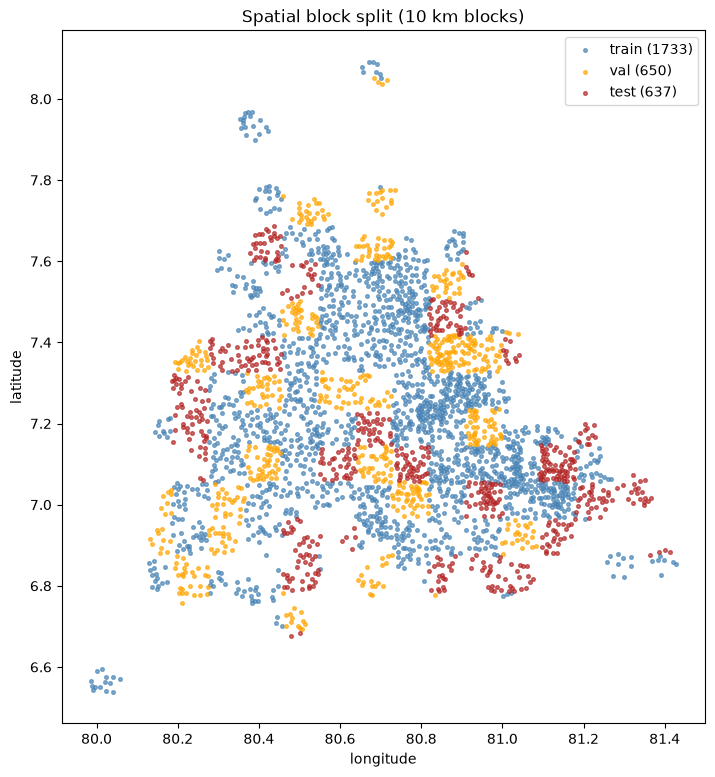

Look for geographic CLUSTERS, not interleaved dots.


In [6]:
colors = {"train": "steelblue", "val": "orange", "test": "firebrick"}
fig, ax = plt.subplots(figsize=(9, 9))
for s, c in colors.items():
    sub = df[df.split == s]
    ax.scatter(sub.longitude, sub.latitude, s=7, c=c, alpha=.65,
               label=f"{s} ({len(sub)})")
ax.set(title=f"Spatial block split ({BLOCK_M/1000:.0f} km blocks)",
       xlabel="longitude", ylabel="latitude")
ax.legend(); ax.set_aspect("equal")
plt.savefig(FIG_DIR / "07_split_map.png", dpi=130, bbox_inches="tight")
plt.show()
print("Look for geographic CLUSTERS, not interleaved dots.")

In [7]:
def build_sample(pid):
    """Return (8, 64, 64) float32 for one patch."""
    with rasterio.open(OPTICAL_DIR / f"{pid}.tif") as s:
        opt = s.read().astype(np.float32) / 10000.0      # L2A reflectance
    with rasterio.open(TERRAIN_DIR / f"{pid}.tif") as s:
        ter = s.read().astype(np.float32)                # slope, hillshade, curv

    ndvi = (opt[3] - opt[2]) / (opt[3] + opt[2] + 1e-6)  # (B08-B04)/(B08+B04)
    return np.concatenate([opt, ndvi[None], ter], axis=0)


s = build_sample(df.landslide_id.iloc[0])
print(f"shape {s.shape}\n")
for i, c in enumerate(CHANNELS):
    print(f"  {i} {c:10s} {s[i].min():9.2f} .. {s[i].max():9.2f}  "
          f"mean {s[i].mean():8.2f}")

assert s.shape == (N_CH, PX, PX)
assert np.isfinite(s).all(), "non-finite values"
assert -1.01 <= s[4].min() and s[4].max() <= 1.01, "NDVI outside [-1, 1]"
assert 0 <= s[5].mean() < 80, "implausible slope"
print("\nCHECKPOINT PASSED")

shape (8, 64, 64)

  0 B02             0.12 ..      0.14  mean     0.13
  1 B03             0.13 ..      0.18  mean     0.15
  2 B04             0.11 ..      0.16  mean     0.12
  3 B08             0.33 ..      0.67  mean     0.47
  4 NDVI            0.37 ..      0.68  mean     0.59
  5 slope           0.00 ..     38.28  mean    21.31
  6 hillshade      39.62 ..    251.23  mean   152.16
  7 curvature      -3.75 ..      3.30  mean     0.05

CHECKPOINT PASSED


In [8]:
X = np.zeros((len(df), N_CH, PX, PX), dtype=np.float32)
bad = []

for i, pid in enumerate(tqdm(df.landslide_id)):
    try:
        X[i] = build_sample(pid)
    except Exception as exc:
        bad.append((pid, repr(exc)))

if bad:
    print(f"{len(bad)} failures:", bad[:5])
    keep = ~df.landslide_id.isin([b[0] for b in bad]).values
    X, df = X[keep], df[keep].reset_index(drop=True)

y = df.label.values.astype(np.int64)
print(f"\nX {X.shape}  {X.nbytes/1e6:.0f} MB")
print(f"y {y.shape}  positive rate {y.mean():.1%}")
assert np.isfinite(X).all(), "non-finite values in X"

  0%|          | 0/3020 [00:00<?, ?it/s]


X (3020, 8, 64, 64)  396 MB
y (3020,)  positive rate 50.1%


In [9]:
tr = (df.split == "train").values
va = (df.split == "val").values
te = (df.split == "test").values
print(f"statistics from {tr.sum()} TRAIN patches only\n")

lo = np.percentile(X[tr], CLIP_PCT[0], axis=(0, 2, 3))
hi = np.percentile(X[tr], CLIP_PCT[1], axis=(0, 2, 3))

Xc   = np.clip(X, lo[None, :, None, None], hi[None, :, None, None])
mean = Xc[tr].mean(axis=(0, 2, 3))
std  = Xc[tr].std(axis=(0, 2, 3)) + 1e-6

stats = {"channels": CHANNELS, "clip_lo": lo.tolist(), "clip_hi": hi.tolist(),
         "mean": mean.tolist(), "std": std.tolist(), "n_train": int(tr.sum())}
(PROC_DIR / "norm_stats.json").write_text(json.dumps(stats, indent=2))

print(f"{'channel':<11}{'clip_lo':>10}{'clip_hi':>10}{'mean':>10}{'std':>10}")
for i, c in enumerate(CHANNELS):
    print(f"{c:<11}{lo[i]:>10.3f}{hi[i]:>10.3f}{mean[i]:>10.3f}{std[i]:>10.3f}")

statistics from 1733 TRAIN patches only

channel       clip_lo   clip_hi      mean       std
B02             0.117     0.235     0.141     0.020
B03             0.128     0.257     0.166     0.023
B04             0.115     0.273     0.151     0.032
B08             0.119     0.616     0.436     0.081
NDVI            0.000     0.636     0.477     0.125
slope           0.420    45.093    17.586    10.567
hillshade      34.974   244.540   168.831    44.199
curvature      -2.298     2.133     0.004     0.736


In [10]:
Xn = ((Xc - mean[None, :, None, None]) / std[None, :, None, None]).astype(np.float32)

np.save(PROC_DIR / "X.npy", Xn)
np.save(PROC_DIR / "y.npy", y)
df.to_csv(PROC_DIR / "dataset_index.csv", index=False)

print(f"X.npy {Xn.shape}  {Xn.nbytes/1e6:.0f} MB")
print(f"range [{Xn.min():.2f}, {Xn.max():.2f}]  mean {Xn.mean():.3f}")
print(f"\nsaved to {PROC_DIR}")

assert abs(Xn[tr].mean()) < 0.05, "train mean should be ~0 after z-scoring"
print("CHECKPOINT PASSED")

X.npy (3020, 8, 64, 64)  396 MB
range [-3.92, 4.76]  mean 0.009

saved to E:\LandSlide-Prediction\data\processed
CHECKPOINT PASSED


In [11]:
# Notebook 06 found positives sit ~255 m higher. Define an overlapping band
# so notebook 08 can re-test performance with elevation controlled.
pos_e, neg_e = df[df.label == 1].elev_mean, df[df.label == 0].elev_mean
lo_e = max(np.percentile(pos_e, 10), np.percentile(neg_e, 10))
hi_e = min(np.percentile(pos_e, 90), np.percentile(neg_e, 90))

df["elev_matched"] = df.elev_mean.between(lo_e, hi_e)
sub = df[df.elev_matched]

print(f"overlapping elevation band: {lo_e:.0f} - {hi_e:.0f} m")
print(f"patches in band: {len(sub)} "
      f"({(sub.label==1).sum()} pos, {(sub.label==0).sum()} neg)")
print(f"\nmean elevation in band — pos {sub[sub.label==1].elev_mean.mean():.0f} m, "
      f"neg {sub[sub.label==0].elev_mean.mean():.0f} m")
print(f"mean slope     in band — pos {sub[sub.label==1].slope_mean.mean():.1f}°, "
      f"neg {sub[sub.label==0].slope_mean.mean():.1f}°")

df.to_csv(PROC_DIR / "dataset_index.csv", index=False)
print("\nelev_matched flag saved for notebook 08")

overlapping elevation band: 295 - 1305 m
patches in band: 1789 (1203 pos, 586 neg)

mean elevation in band — pos 728 m, neg 705 m
mean slope     in band — pos 22.4°, neg 16.6°

elev_matched flag saved for notebook 08


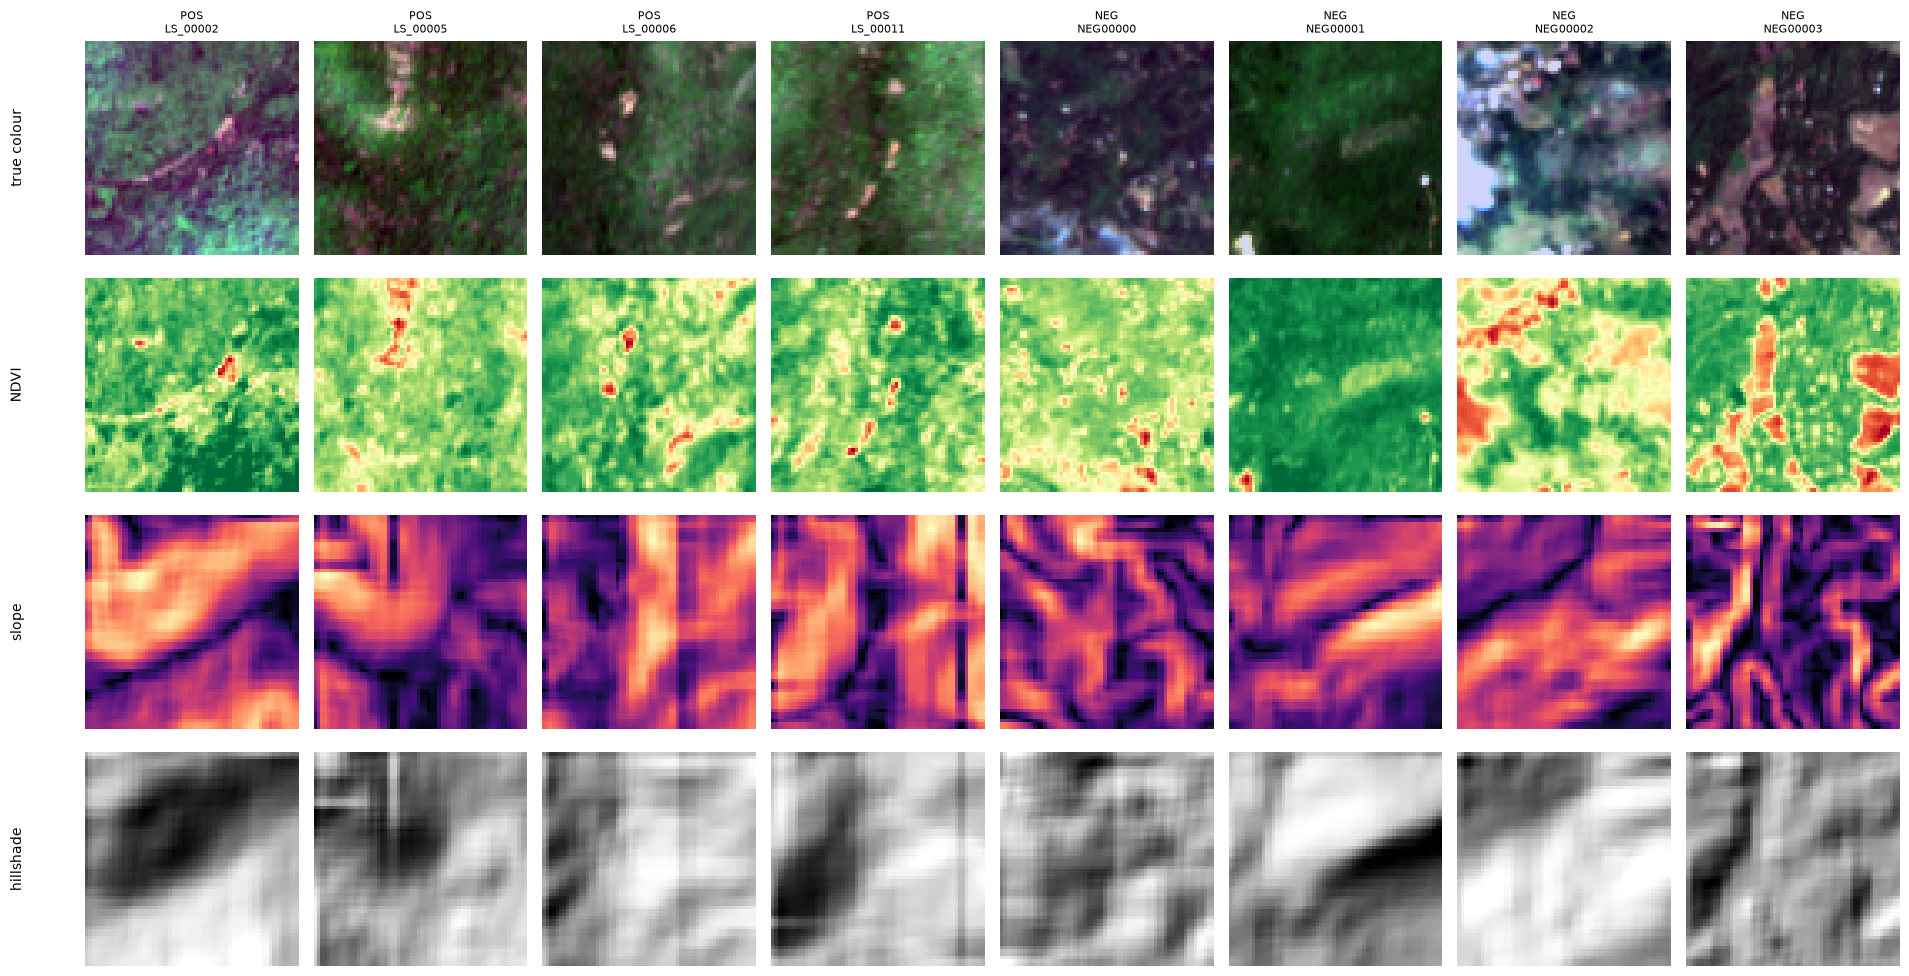

In [12]:
idx = np.concatenate([np.where(y == 1)[0][:4], np.where(y == 0)[0][:4]])
show  = [(2, 1, 0), 4, 5, 6]
names = ["true colour", "NDVI", "slope", "hillshade"]
cmaps = [None, "RdYlGn", "magma", "gray"]

fig, axes = plt.subplots(4, 8, figsize=(19, 10))
for j, i in enumerate(idx):
    for r, (ch, nm, cm) in enumerate(zip(show, names, cmaps)):
        ax = axes[r, j]
        if isinstance(ch, tuple):
            img = np.dstack([Xn[i, c] for c in ch])
            img = (img - img.min()) / (np.ptp(img) + 1e-6)
            ax.imshow(img)
        else:
            ax.imshow(Xn[i, ch], cmap=cm)
        ax.axis("off")
        if r == 0:
            ax.set_title(f"{'POS' if y[i] else 'NEG'}\n"
                         f"{df.landslide_id.iloc[i]}", fontsize=8)
        if j == 0:
            ax.text(-.35, .5, nm, transform=ax.transAxes, rotation=90,
                    va="center", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_samples.png", dpi=130, bbox_inches="tight")
plt.show()

channel       pos mean   neg mean     diff
------------------------------------------
B02             -0.024      0.086   -0.111
B03              0.047      0.000    0.047
B04              0.007      0.009   -0.002
B08              0.155     -0.136    0.290
NDVI             0.099     -0.085    0.184
slope            0.391     -0.414    0.805
hillshade       -0.131      0.131   -0.262
curvature        0.004     -0.003    0.007


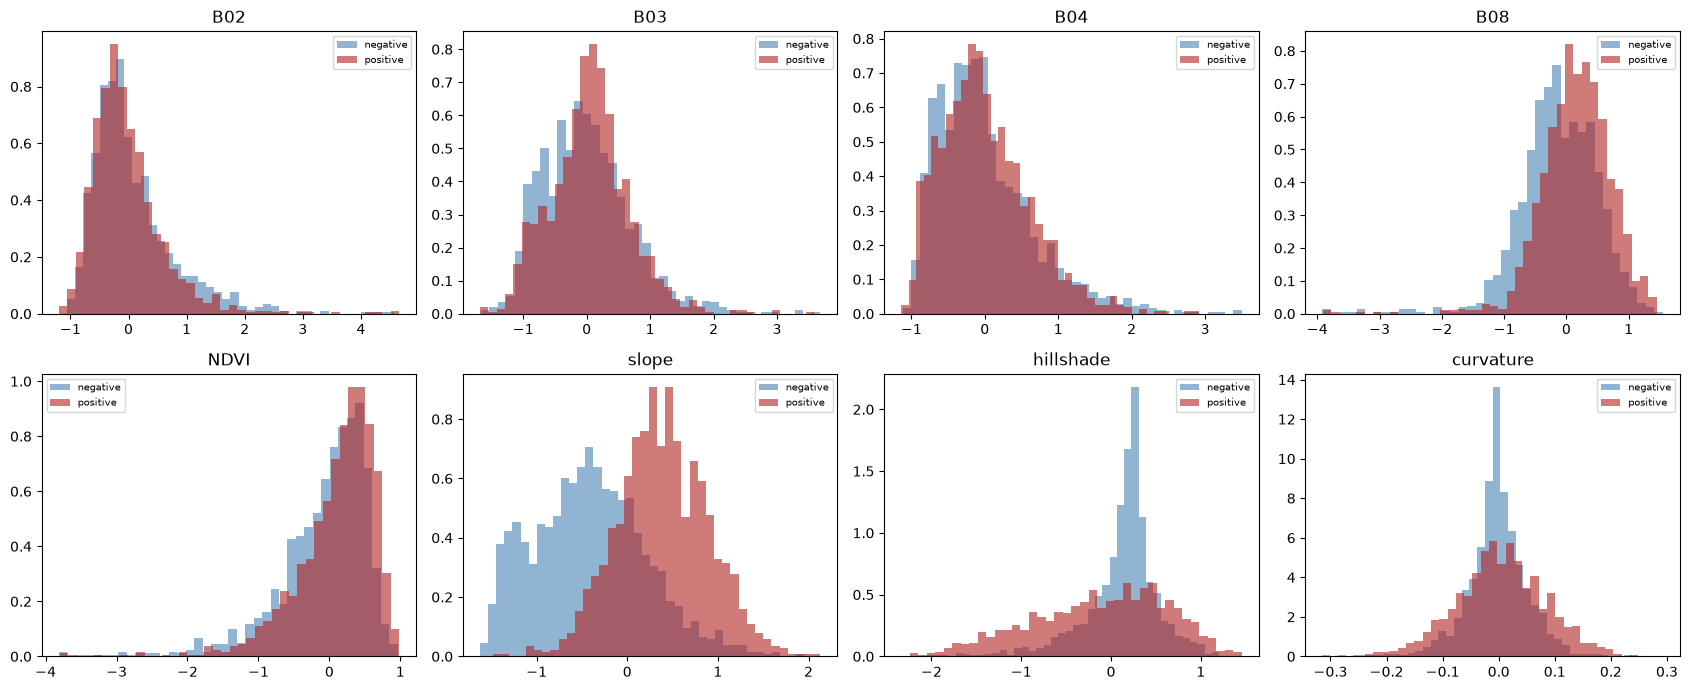

In [13]:
print(f"{'channel':<11}{'pos mean':>11}{'neg mean':>11}{'diff':>9}")
print("-" * 42)
for i, c in enumerate(CHANNELS):
    p, n = Xn[y == 1, i].mean(), Xn[y == 0, i].mean()
    print(f"{c:<11}{p:>11.3f}{n:>11.3f}{p-n:>9.3f}")

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for i, (ax, c) in enumerate(zip(axes.ravel(), CHANNELS)):
    ax.hist(Xn[y == 0, i].mean(axis=(1, 2)), bins=40, alpha=.6,
            label="negative", color="steelblue", density=True)
    ax.hist(Xn[y == 1, i].mean(axis=(1, 2)), bins=40, alpha=.6,
            label="positive", color="firebrick", density=True)
    ax.set_title(c); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_channel_separation.png", dpi=130, bbox_inches="tight")
plt.show()

In [14]:
print("FINAL CHECKS")
print("-" * 46)
checks = {
    "X.npy exists":        (PROC_DIR / "X.npy").exists(),
    "y.npy exists":        (PROC_DIR / "y.npy").exists(),
    "split.csv exists":    (SPLIT_DIR / "split.csv").exists(),
    "norm_stats exists":   (PROC_DIR / "norm_stats.json").exists(),
    "shape correct":       Xn.shape[1:] == (N_CH, PX, PX),
    "all finite":          bool(np.isfinite(Xn).all()),
    "both classes":        len(np.unique(y)) == 2,
    "3 splits present":    df.split.nunique() == 3,
    "blocks exclusive":    bool((df.groupby('block_id').split.nunique() == 1).all()),
    "elev_matched flag":   "elev_matched" in df.columns,
}
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")
assert all(checks.values()), "Some checks failed"
print("\nDATASET READY")

FINAL CHECKS
----------------------------------------------
  PASS  X.npy exists
  PASS  y.npy exists
  PASS  split.csv exists
  PASS  norm_stats exists
  PASS  shape correct
  PASS  all finite
  PASS  both classes
  PASS  3 splits present
  PASS  blocks exclusive
  PASS  elev_matched flag

DATASET READY


## Checklist

- [ ] Cell 3  — complete patches found, classes balanced
- [ ] Cell 6  — no block spans two splits; train-test distance >= 640 m
- [ ] Cell 7  — split map shows clusters, not interleaving
- [ ] Cell 8  — single sample has valid NDVI and slope ranges
- [ ] Cell 11 — train mean ~0 after normalisation
- [ ] Cell 12 — elevation-matched subset defined
- [ ] Cell 15 — all final checks PASS

split.csv is FROZEN. Do not regenerate it once training has begun.

Commit: "Add 8-channel dataset assembly, spatial split and train-only normalisation"

Next: 08_baselines.ipynb